# Practice 01 — 파이썬 기초

이 노트북은 AI / 머신러닝 코드를 읽고 쓰기 위해 필요한 **파이썬 기본기**를 다룬다.

### 학습 목표
- 파이썬의 기본 자료형과 연산자를 이해한다
- 핵심 자료구조인 리스트, 튜플, 딕셔너리를 사용한다
- 조건문과 반복문으로 프로그램의 흐름을 제어한다
- 함수를 정의하고 호출한다
- 클래스와 상속을 이해한다
- NumPy 배열과 Matplotlib 시각화를 시작한다

### 목차

| 절 | 주제 |
|:---:|------|
| 0 | 용어 정리 |
| 1 | 변수와 자료형 |
| 2 | 자료구조 (list, tuple, dict) |
| 3 | 제어문 (조건문, 반복문) |
| 4 | 함수 |
| 5 | 리스트 컴프리헨션과 람다 함수 |
| 6 | 문자열 포매팅 |
| 7 | 클래스와 객체지향 프로그래밍 |
| 8 | NumPy 기초 |
| 9 | Matplotlib 기초 |
| 10 | 데이터 불러오기 |
| 11 | Pandas 기초 |
| 12 | 정리 |

### Jupyter Notebook 사용법

| 단축키 | 동작 |
|--------|------|
| `Shift + Enter` | 현재 셀을 실행하고 다음 셀로 이동 |
| `Ctrl + Enter` | 현재 셀을 실행하고 그 자리에 머무름 |
| `Esc` | 편집 모드에서 빠져나옴 (아래 단축키가 동작하게 됨) |
| `A` | 위에 새 셀 삽입 |
| `B` | 아래에 새 셀 삽입 |
| `M` | 셀을 마크다운으로 변경 |
| `Y` | 셀을 코드로 변경 |

- 셀 왼쪽의 표시: `[ ]` 실행 전 &nbsp;|&nbsp; `[*]` 실행 중 &nbsp;|&nbsp; `[숫자]` 실행 완료
- **읽으면서 코드 셀을 직접 고쳐 다시 실행해 볼 것 — 이 노트북은 그렇게 쓰라고 만든 것이다.**

### Google Colab 사용법

[Google Colab](https://colab.research.google.com/) 은 브라우저에서 바로 파이썬 코드를 실행하는
**클라우드 기반 Jupyter 환경**이다.
설치할 것이 없고 GPU 도 쓸 수 있어서 딥러닝 실습에 편하다.

#### 로컬 Jupyter Notebook 과의 주요 차이

| 항목 | Jupyter Notebook (로컬) | Google Colab |
|------|------------------------|--------------|
| 코드 실행 위치 | 내 컴퓨터 | 구글 서버 (클라우드) |
| 설치 | Python + Jupyter 필요 | 브라우저만 있으면 됨 |
| GPU | 별도 설정 필요 | **런타임 -> 런타임 유형 변경 -> GPU** |
| 파일 저장 | 로컬 디스크 | Google Drive |
| 커널 메뉴 | Kernel | **런타임** |
| 세션 | 직접 종료할 때까지 유지 | **일정 시간 놀리면 자동 해제** |

#### 자주 쓰는 단축키 (Jupyter 와 다른 것들)

| 단축키 | 동작 |
|--------|------|
| `Ctrl + M, B` | 아래에 새 셀 삽입 (Jupyter 는 `B` 만) |
| `Ctrl + M, A` | 위에 새 셀 삽입 (Jupyter 는 `A` 만) |
| `Ctrl + M, M` | 셀을 마크다운으로 변경 |
| `Ctrl + M, Y` | 셀을 코드로 변경 |
| `Ctrl + M, D` | 셀 삭제 (Jupyter 는 `D, D`) |
| `Ctrl + /` | 선택한 부분의 주석 토글 |

> Colab 은 `Esc` 대신 `Ctrl + M` 으로 명령 모드에 들어간다.

#### Colab 에서만 되는 기능

```python
# (1) GPU 사용 가능 여부 확인
import torch
print(torch.cuda.is_available())   # True 면 GPU 사용 가능

# (2) 데이터 파일을 읽기 위해 Google Drive 연결
from google.colab import drive
drive.mount('/content/drive')

# (3) 셀에서 바로 패키지 설치
!pip install some_package

# (4) 파일 업로드 / 다운로드
from google.colab import files
files.upload()                     # 내 컴퓨터 -> Colab
files.download('result.csv')       # Colab -> 내 컴퓨터
```

> **참고:** Colab 세션은 약 90분간 아무 조작이 없으면 **자동으로 연결이 끊긴다.**
> 그 전에 중요한 결과는 Google Drive 에 저장하거나 `files.download()` 로 내려받아 둘 것.

In [1]:
# 첫 번째 파이썬 코드 실행하기
print("안녕하세요, 기계공학!")
print("AI 수업에 오신 것을 환영합니다!")

안녕하세요, 기계공학!
AI 수업에 오신 것을 환영합니다!


---
# 0. 용어와 기본 개념

코드를 읽기 전에, 계속 반복해서 나오는 용어를 먼저 정리한다.

| 용어 | 의미 | 예시 |
|------|------|------|
| **변수 (variable)** | 데이터를 담아 두는 이름 | `x = 10` |
| **함수 (function)** | `이름()` 형태로 호출하는 것 | `print()`, `len()` |
| **라이브러리 (library)** | 남이 만들어 둔 함수 모음, `import` 로 가져옴 | `import numpy as np` |
| **라이브러리 함수** | 라이브러리 안에 들어 있는 함수: `라이브러리.함수()` | `np.sqrt()`, `np.mean()` |
| **메서드 (method)** | 변수에 붙어 있는 함수: `변수.메서드()` — 괄호가 있다 | `arr.reshape(2, 3)` |
| **속성 (attribute)** | 변수가 갖고 있는 정보: `변수.속성` — 괄호가 없다 | `arr.shape`, `arr.dtype` |

In [2]:
# 라이브러리: import 로 가져온다
import numpy as np

# 라이브러리 안의 함수 호출: np.함수이름()
arr = np.array([1, 2, 3, 4, 5, 6])
print(np.sqrt(16))              # np 안에 있는 sqrt 함수
print(np.mean(arr))             # np 안에 있는 mean 함수

# 메서드: 변수에 붙어 있는 함수 -> 변수.메서드()
print(arr.reshape(2, 3))        # arr 에 붙어 있는 reshape 메서드
print(arr.sum())                # arr 에 붙어 있는 sum 메서드

# 속성: 변수가 갖고 있는 정보 -> 변수.속성 (괄호 없음)
print(arr.shape)                # 배열의 크기
print(arr.dtype)                # 배열의 자료형

# 변수가 가진 메서드와 속성 목록 보기 (Colab 에서는 arr. 을 입력하고 Tab 을 눌러도 된다)
print(dir(arr))

4.0
3.5
[[1 2 3]
 [4 5 6]]
21
(6,)
int64
['T', '__abs__', '__add__', '__and__', '__array__', '__array_finalize__', '__array_function__', '__array_interface__', '__array_namespace__', '__array_priority__', '__array_struct__', '__array_ufunc__', '__array_wrap__', '__bool__', '__buffer__', '__class__', '__class_getitem__', '__complex__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dir__', '__divmod__', '__dlpack__', '__dlpack_device__', '__doc__', '__eq__', '__float__', '__floordiv__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__ilshift__', '__imatmul__', '__imod__', '__imul__', '__index__', '__init__', '__init_subclass__', '__int__', '__invert__', '__ior__', '__ipow__', '__irshift__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lshift__', '__lt__', '__matmul__', '__mod__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__

In [3]:
# print 와 f-string: 변수의 값을 화면에 보여 주는 방법
lecture_number = 1
topic = "파이썬 기초"

print("안녕하세요, 기계공학!")                       # 고정된 문자열
print(f"이번은 {lecture_number}번째 강의입니다")      # f"...{변수}..." 는 변수의 값을 넣어 준다
print(f"주제: {topic}")                              # 문자열 변수도 마찬가지
print(f"다음 강의: {lecture_number + 1}번째")        # 중괄호 안에서 계산도 가능하다

안녕하세요, 기계공학!
이번은 1번째 강의입니다
주제: 파이썬 기초
다음 강의: 2번째


---
# 1. 변수와 자료형

파이썬에서 **변수**는 데이터에 붙인 이름이다.
C 나 MATLAB 과 달리 변수를 만들 때 **자료형을 선언하지 않는다.**

> **왜 중요한가.** 머신러닝에서 데이터 자체는 숫자(`int`, `float`)이고,
> 모델의 출력은 문자열(`str`)이나 참/거짓(`bool`)으로 다시 읽는 경우가 많다.

### 1.1 기본 자료형

In [4]:
# 정수 (int) - 측정 횟수, 샘플 개수 등
num_samples = 100         # 학습 샘플 개수
num_features = 4          # 특징 개수 (예: iris 데이터)
print(num_samples, type(num_samples))

# 실수 (float) - 온도, 압력, 학습률 등
temperature = 25.3        # 섭씨 온도
lr = 0.001                # 학습률
pi = 3.14159
print(temperature, type(temperature))
print(lr, type(lr))

100 <class 'int'>
25.3 <class 'float'>
0.001 <class 'float'>


In [5]:
# 문자열 (str) - 파일 경로, 레이블 이름 등
material = "Steel"
label = 'setosa'          # 붓꽃 품종 이름
file_path = "data/iris.csv"
print(material, type(material))

# 불리언 (bool) - 조건, GPU 사용 여부 등
is_training = True
use_gpu = False
print(is_training, type(is_training))

# 비교 연산의 결과도 bool 이다
print(1 > 2, type(1 > 2))        # False
print(10 >= 10, type(10 >= 10))  # True

Steel <class 'str'>
True <class 'bool'>
False <class 'bool'>
True <class 'bool'>


### 1.2 산술 연산자

| 연산자 | 의미 | 예시 | 결과 |
|:---:|------|------|:---:|
| `+` | 덧셈 | `3 + 2` | `5` |
| `-` | 뺄셈 | `3 - 2` | `1` |
| `*` | 곱셈 | `3 * 2` | `6` |
| `/` | 나눗셈 | `7 / 2` | `3.5` |
| `//` | 몫 | `7 // 2` | `3` |
| `%` | 나머지 | `7 % 2` | `1` |
| `**` | 거듭제곱 | `3 ** 2` | `9` |

In [6]:
# 공학 예제: 원형 단면의 면적과 단면 2차 모멘트
import math

radius = 0.05  # 반지름 50 mm = 0.05 m

area = math.pi * radius ** 2                    # 면적 A = pi * r^2
moment_of_inertia = math.pi * radius ** 4 / 4   # 단면 2차 모멘트 I = pi * r^4 / 4

print("단면적:", area, "m^2")
print("단면 2차 모멘트:", moment_of_inertia, "m^4")

단면적: 0.007853981633974483 m^2
단면 2차 모멘트: 4.9087385212340526e-06 m^4


### 1.3 자료형 변환

머신러닝 코드에서는 자료형 변환이 끊임없이 일어난다.
이미지 데이터를 정수(0-255)에서 실수(0.0-1.0)로 `float()` 변환하는 것이 대표적이다.

In [7]:
# 자료형 변환
pixel_value = 128                        # 이미지의 픽셀 값 (0-255 정수)
normalized = float(pixel_value) / 255.0  # 정규화: 0.0-1.0 범위의 실수로 변환
print(f"원본: {pixel_value}, 자료형: {type(pixel_value)}")
print(f"정규화: {normalized:.4f}, 자료형: {type(normalized)}")  # :.4f 는 소수점 4자리 출력 (6절)

# 문자열 -> 숫자
epoch_str = "100"
epoch_num = int(epoch_str)
print(f"문자열 '{epoch_str}' -> 정수 {epoch_num}")

원본: 128, 자료형: <class 'int'>
정규화: 0.5020, 자료형: <class 'float'>
문자열 '100' -> 정수 100


### 1.4 대입과 다중 대입

파이썬에서는 한 줄에 여러 변수를 한꺼번에 대입할 수 있다.
데이터셋을 불러오는 ML 코드에서 이 형태가 **끊임없이** 등장한다.

```python
# 자주 보게 될 코드:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
```

In [8]:
# 다중 대입
width, height, channels = 28, 28, 1   # MNIST 이미지 크기
print(f"이미지 크기: {width} x {height} x {channels}")

# 값 교환 - 다른 언어보다 훨씬 짧다
a, b = 10, 20
print(f"교환 전: a={a}, b={b}")
a, b = b, a
print(f"교환 후: a={a}, b={b}")

이미지 크기: 28 x 28 x 1
교환 전: a=10, b=20
교환 후: a=20, b=10


### 연습문제 1

1. 변수 `force` 에 100.0 (단위: N), `area` 에 0.01 (단위: m^2) 을 저장하고
   응력(`stress = force / area`)을 계산해 출력하라.
2. `type()` 으로 결과의 자료형을 확인하라.
3. 결과를 정수(`int`)로 변환해 출력하라.

In [9]:
# 연습문제 1 - 여기에 답을 작성하세요

---
# 2. 자료구조

파이썬의 핵심 자료구조인 **리스트(list)**, **튜플(tuple)**, **딕셔너리(dict)** 를 다룬다.

> **왜 중요한가.**
> - **list**: 학습 손실 기록, 예측 결과 수집 (`losses = []`, `losses.append(...)`)
> - **tuple**: 이미지 형태 `(28, 28, 1)`, 커널 크기 `(3, 3)` 처럼 바뀌면 안 되는 값
> - **dict**: 하이퍼파라미터 설정, 학습 기록 (`history['accuracy']`)

### 2.1 리스트 (list)

In [10]:
# 리스트 - 순서가 있고 값을 바꿀 수 있는 데이터 묶음
# ML 에서 학습 과정을 기록할 때 없어서는 안 된다

# 리스트 만들기
scores = [92, 87, 95, 78, 88]
print("시험 점수:", scores)
print("학생 수:", len(scores))
print("첫 번째:", scores[0])
print("마지막:", scores[-1])      # 음수 인덱스는 뒤에서부터 센다

# 빈 리스트를 만들고 append 로 채우기
losses = []
losses.append(2.35)               # 1 에포크의 손실
losses.append(1.82)               # 2 에포크의 손실
losses.append(0.95)               # 3 에포크의 손실
print("기록된 손실:", losses)

시험 점수: [92, 87, 95, 78, 88]
학생 수: 5
첫 번째: 92
마지막: 88
기록된 손실: [2.35, 1.82, 0.95]


In [11]:
# 인덱싱과 슬라이싱 - NumPy 배열 조작의 기초가 된다
# 파이썬의 인덱스는 0 부터 시작한다

feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

print("첫 번째:     ", feature_names[0])     # 첫 번째 원소
print("마지막:      ", feature_names[-1])    # 마지막 원소
print("인덱스 1~2:  ", feature_names[1:3])   # 인덱스 1 부터 2 까지 (3 은 제외)
print("처음~인덱스 1:", feature_names[:2])   # 처음부터 인덱스 1 까지
print("인덱스 2~끝: ", feature_names[2:])    # 인덱스 2 부터 끝까지

첫 번째:      sepal_length
마지막:       petal_width
인덱스 1~2:   ['sepal_width', 'petal_length']
처음~인덱스 1: ['sepal_length', 'sepal_width']
인덱스 2~끝:  ['petal_length', 'petal_width']


In [12]:
# 리스트 연산과 메서드
layers = [784, 128, 64]
layers.append(10)               # 맨 뒤에 추가
print("신경망 구조:", layers)

layers.insert(1, 256)           # 인덱스 1 위치에 삽입
print("층을 추가한 뒤:", layers)

layers.remove(256)              # 값을 지정해 제거
print("층을 제거한 뒤:", layers)

# 리스트 이어 붙이기
train_acc = [0.8, 0.85, 0.9]
test_acc = [0.75, 0.80, 0.85]
all_acc = train_acc + test_acc
print("\n전체 정확도:", all_acc)

# 정렬
scores = [92, 87, 95, 78, 88]
print("오름차순:", sorted(scores))
print("내림차순:", sorted(scores, reverse=True))

신경망 구조: [784, 128, 64, 10]
층을 추가한 뒤: [784, 256, 128, 64, 10]
층을 제거한 뒤: [784, 128, 64, 10]

전체 정확도: [0.8, 0.85, 0.9, 0.75, 0.8, 0.85]
오름차순: [78, 87, 88, 92, 95]
내림차순: [95, 92, 88, 87, 78]


### 2.2 튜플 (tuple)

튜플은 리스트와 비슷하지만 **값을 바꿀 수 없다.** ML / DL 코드에서는 데이터의 형태나 커널 크기처럼
바뀌면 안 되는 값에 쓴다.

```python
# 자주 보게 될 코드:
input_shape = (28, 28, 1)
kernel_size = (3, 3)
pool_size = (2, 2)
```

In [13]:
# 튜플 - 값을 바꿀 수 없는 데이터 묶음
image_shape = (28, 28, 1)     # (높이, 너비, 채널)
kernel_size = (3, 3)
pool_size = (2, 2)

print(f"이미지 형태: {image_shape}")
print(f"높이: {image_shape[0]}, 너비: {image_shape[1]}, 채널: {image_shape[2]}")

# 튜플 언패킹
height, width, channels = image_shape
print(f"H={height}, W={width}, C={channels}")

# 튜플은 수정할 수 없다
# image_shape[0] = 32  # 이 줄의 주석을 풀면 TypeError 가 난다

이미지 형태: (28, 28, 1)
높이: 28, 너비: 28, 채널: 1
H=28, W=28, C=1


### 2.3 딕셔너리 (dict)

딕셔너리는 **키(key)-값(value)** 쌍으로 데이터를 저장한다.
ML 에서는 하이퍼파라미터 설정이나 학습 기록을 담는 데 쓴다.

In [14]:
# 딕셔너리 - 하이퍼파라미터를 관리하기에 편하다
hyperparams = {
    'lr': 0.001,
    'batch_size': 128,
    'epochs': 30,
    'optimizer': 'Adam'
}

print("학습률:", hyperparams['lr'])
print("배치 크기:", hyperparams['batch_size'])

# 값 수정과 추가
hyperparams['epochs'] = 50           # 이미 있는 키의 값을 변경
hyperparams['dropout_rate'] = 0.5    # 새로운 키-값 쌍을 추가
print("\n수정 후:", hyperparams)

# 키와 값에 접근하기
print("\n키:  ", list(hyperparams.keys()))
print("값:  ", list(hyperparams.values()))

# 키-값 쌍을 한 번에 순회하기 (for 반복문은 3절에서 다룬다)
print("\n전체 설정:")
for key, value in hyperparams.items():
    print(f"  {key}: {value}")

학습률: 0.001
배치 크기: 128

수정 후: {'lr': 0.001, 'batch_size': 128, 'epochs': 50, 'optimizer': 'Adam', 'dropout_rate': 0.5}

키:   ['lr', 'batch_size', 'epochs', 'optimizer', 'dropout_rate']
값:   [0.001, 128, 50, 'Adam', 0.5]

전체 설정:
  lr: 0.001
  batch_size: 128
  epochs: 50
  optimizer: Adam
  dropout_rate: 0.5


In [15]:
# 딕셔너리로 학습 기록 남기기 (실제 ML 코드에서 쓰는 형태)
history = {'accuracy': [], 'loss': []}

# 1 에포크
history['accuracy'].append(0.65)
history['loss'].append(2.1)

# 2 에포크
history['accuracy'].append(0.78)
history['loss'].append(1.5)

# 3 에포크
history['accuracy'].append(0.85)
history['loss'].append(0.9)

print(f"학습 기록: {history}")
print(f"최종 정확도: {history['accuracy'][-1]}")
print(f"에포크 수: {len(history['accuracy'])}")

학습 기록: {'accuracy': [0.65, 0.78, 0.85], 'loss': [2.1, 1.5, 0.9]}
최종 정확도: 0.85
에포크 수: 3


### 2.4 세 자료구조 비교

| 성질 | list `[ ]` | tuple `( )` | dict `{ }` |
|:---:|:---:|:---:|:---:|
| 수정 가능 | O | **X** | O |
| 순서 있음 | O | O | O (3.7+) |
| 접근 방식 | 번호 | 번호 | 키 |
| ML 에서의 용도 | 값 기록 | 형태, 크기 | 설정, 기록 |

### 연습문제 2

1. 온도 측정값 다섯 개 `[22.1, 23.5, 21.8, 24.2, 22.9]` 로 리스트를 만들고,
   슬라이싱으로 **앞의 세 개만** 출력하라.
2. 보를 딕셔너리로 표현하라: `length` = 2.0 m, `material` = "Steel", `area` = 0.01 m^2.
   그 다음 `'material'` 키의 값을 출력하라.
3. `history = {'score': [], 'passed': []}` 를 만들어라.
   학생 점수 `[85, 42, 73]` 에 대해 각 점수를 `'score'` 에 추가하고,
   60점 이상이면 `True`, 아니면 `False` 를 `'passed'` 에 추가하라.
   최종 `history` 를 출력하라.
4. 빈 리스트를 만들고 1, 4, 9, 16, 25 를 `append` 한 뒤 전체를 출력하라.

In [16]:
# 연습문제 2 - 여기에 답을 작성하세요

---
# 3. 제어문

문장이 실행되는 순서를 제어하는 문법이다.

> **왜 중요한가.**
> - **비교 / 논리 연산자**: 조건이 성립하는지 판단
> - `if/elif/else`: 예측 결과 분류, GPU 사용 여부 결정
> - `for` 반복문: **에포크 반복**, 배치 처리, 평가
> - `while` 반복문: 수렴 조건 확인

> **주의.** 파이썬은 C 나 Java 의 중괄호 `{}` 가 아니라 **들여쓰기**로 코드 블록을 구분한다.
> 한 단계에 **공백 네 칸**을 쓴다.

### 3.1 비교 연산자와 논리 연산자

In [17]:
# 비교 연산자 - ML 코드에서 분기 판단에 끊임없이 쓴다
accuracy = 0.95
threshold = 0.90

print("accuracy > threshold :", accuracy > threshold)   # True
print("accuracy == 1.0      :", accuracy == 1.0)        # False
print("accuracy >= 0.95     :", accuracy >= 0.95)       # True
print("accuracy != threshold:", accuracy != threshold)  # True

# 논리 연산자
is_accurate = accuracy > 0.90
is_fast = True
print("\nis_accurate and is_fast:", is_accurate and is_fast)  # 둘 다 True 일 때만 True
print("is_accurate or is_fast :", is_accurate or is_fast)     # 하나라도 True 면 True
print("not is_accurate        :", not is_accurate)            # 부정

accuracy > threshold : True
accuracy == 1.0      : False
accuracy >= 0.95     : True
accuracy != threshold: True

is_accurate and is_fast: True
is_accurate or is_fast : True
not is_accurate        : False


### 3.2 조건문 (if / elif / else)

In [18]:
# 조건문 - 정확도로 모델의 등급을 매긴다
accuracy = 0.87

if accuracy >= 0.95:
    grade = "우수"
elif accuracy >= 0.90:
    grade = "양호"
elif accuracy >= 0.80:
    grade = "보통"
else:
    grade = "개선 필요"

print(f"정확도: {accuracy*100}% -> 등급: {grade}")

정확도: 87.0% -> 등급: 보통


In [19]:
# 조건 표현식 - 실제 ML 코드에서 자주 나오는 형태
import random

# GPU 사용 가능 여부에 따라 장치를 선택한다
# (실제 코드에서는 torch.cuda.is_available() 을 호출한다)
gpu_available = random.choice([True, False])  # 여기서는 흉내만 낸다

# if-else 로 쓴 경우
if gpu_available:
    device = 'cuda'
else:
    device = 'cpu'
print(f"GPU 사용 가능: {gpu_available} -> 장치: {device}")

# 같은 내용을 한 줄짜리 조건 표현식으로
device = 'cuda' if gpu_available else 'cpu'
print(f"조건 표현식: {device}")

GPU 사용 가능: False -> 장치: cpu
조건 표현식: cpu


### 3.3 `for` 반복문

```python
# 자주 보게 될 코드:
for epoch in range(n_epochs):
    for i, (X_batch, y_batch) in enumerate(dataloader):
        loss = train_step(X_batch, y_batch)
```

In [20]:
# range() - 연속된 숫자를 만든다
print("range(5)       :", list(range(5)))         # [0, 1, 2, 3, 4]
print("range(1, 6)    :", list(range(1, 6)))      # [1, 2, 3, 4, 5]
print("range(0, 10, 2):", list(range(0, 10, 2)))  # [0, 2, 4, 6, 8]

print()

# 에포크 반복 (모든 ML 학습 루프의 뼈대)
n_epochs = 5
for epoch in range(n_epochs):
    print(f"에포크 {epoch+1}/{n_epochs}")

range(5)       : [0, 1, 2, 3, 4]
range(1, 6)    : [1, 2, 3, 4, 5]
range(0, 10, 2): [0, 2, 4, 6, 8]

에포크 1/5
에포크 2/5
에포크 3/5
에포크 4/5
에포크 5/5


In [21]:
# enumerate() - 인덱스와 값을 동시에 얻는다 (ML 코드에서 매우 흔하다)
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for idx, name in enumerate(feature_names):
    print(f"특징 {idx}: {name}")

특징 0: sepal_length
특징 1: sepal_width
특징 2: petal_length
특징 3: petal_width


In [22]:
# zip() - 두 리스트를 나란히 순회한다
models = ['KNN', 'SVM', 'Random Forest']
accuracies = [0.93, 0.87, 0.91]

for model, accuracy in zip(models, accuracies):
    print(f"{model}: {accuracy*100:.1f}%")

KNN: 93.0%
SVM: 87.0%
Random Forest: 91.0%


In [23]:
# 중첩 반복문 - 딥러닝 학습 루프의 뼈대
import random

n_epochs = 3
n_batches = 4  # 실제 코드에서는 len(train_loader) 이다

for epoch in range(n_epochs):
    total_loss = 0
    for batch_idx in range(n_batches):
        batch_loss = random.random()  # 손실값을 흉내낸 것
        total_loss += batch_loss
    avg_loss = total_loss / n_batches
    print(f"에포크 [{epoch+1}/{n_epochs}], 평균 손실: {avg_loss:.4f}")

에포크 [1/3], 평균 손실: 0.5212
에포크 [2/3], 평균 손실: 0.5868
에포크 [3/3], 평균 손실: 0.4048


### 3.4 `while` 반복문

In [24]:
# 예제: 손실이 충분히 작아질 때까지 학습을 계속한다

loss = 10.0
threshold = 0.5
iteration = 0

while loss > threshold:    # loss 가 threshold 보다 큰 동안 반복
    loss = loss * 0.7      # 한 번 반복할 때마다 30% 감소 (흉내)
    iteration += 1

print(f"{iteration}번 반복 후 수렴, 최종 손실 = {loss:.4f}")

9번 반복 후 수렴, 최종 손실 = 0.4035


In [25]:
# break 와 continue
# 조기 종료: 검증 손실이 더 좋아지지 않으면 학습을 멈춘다

val_losses = [2.1, 1.8, 1.5, 1.3, 1.4, 1.6, 1.8]
patience = 2              # 개선이 없어도 참아 주는 에포크 수
no_improve_count = 0
best_loss = float('inf')  # 무한대로 초기화

for epoch, val_loss in enumerate(val_losses):
    if val_loss < best_loss:
        best_loss = val_loss
        no_improve_count = 0
        print(f"에포크 {epoch+1}: val_loss={val_loss:.2f} (개선)")
    else:
        no_improve_count += 1
        print(f"에포크 {epoch+1}: val_loss={val_loss:.2f} (개선 없음 {no_improve_count}/{patience})")

    if no_improve_count >= patience:
        print(f"\n>> 에포크 {epoch+1} 에서 조기 종료")
        break

에포크 1: val_loss=2.10 (개선)
에포크 2: val_loss=1.80 (개선)
에포크 3: val_loss=1.50 (개선)
에포크 4: val_loss=1.30 (개선)
에포크 5: val_loss=1.40 (개선 없음 1/2)
에포크 6: val_loss=1.60 (개선 없음 2/2)

>> 에포크 6 에서 조기 종료


### 연습문제 3

1. `for` 반복문으로 1 부터 100 까지 중 **3의 배수의 합**을 구하라.
2. 리스트 `temperatures = [22, 35, 18, 40, 25, 38, 15]` 에서 **30도 이상인 값만** 출력하라.
3. (도전) `for` 반복문으로 구구단 5단을 `5 x 1 = 5` 형식으로 출력하라.

In [26]:
# 연습문제 3 - 여기에 답을 작성하세요

---
# 4. 함수

함수는 반복되는 코드를 **재사용 가능한 블록**으로 묶은 것이다.

> **왜 중요한가.** ML / DL 코드는 함수를 중심으로 구성된다.
> 전처리 함수, 학습 함수, 평가 함수가 그렇다.
> scikit-learn 의 `.fit()`, `.predict()`, `.transform()` 도 모두 함수(메서드)다.

### 4.1 함수의 기본

In [27]:
# 함수 정의와 호출
def calculate_stress(force, area):
    # force: 가해진 힘, 단위 N
    # area: 단면적, 단위 m^2
    # 응력을 Pa 단위로 반환한다
    stress = force / area
    return stress

# 함수 호출
result = calculate_stress(1000, 0.01)
print(f"응력: {result} Pa")
print(f"응력: {result/1e6} MPa")

응력: 100000.0 Pa
응력: 0.1 MPa


In [28]:
# 기본값 매개변수 - ML 모델을 설정할 때 반드시 필요하다
# sklearn 에서 어디서나 쓰인다: SVC(kernel='rbf', C=1.0), MLPClassifier(hidden_layer_sizes=(100,))

def create_model_config(n_layers=3, lr=0.001, optimizer='Adam'):
    # 모델 설정을 딕셔너리로 반환한다
    config = {
        'n_layers': n_layers,
        'lr': lr,
        'optimizer': optimizer
    }
    return config

# 기본값을 그대로 사용
config1 = create_model_config()
print("기본 설정:", config1)

# 일부 값만 바꿔서 사용
config2 = create_model_config(n_layers=5, lr=0.01)
print("수정한 설정:", config2)

기본 설정: {'n_layers': 3, 'lr': 0.001, 'optimizer': 'Adam'}
수정한 설정: {'n_layers': 5, 'lr': 0.01, 'optimizer': 'Adam'}


In [29]:
# 여러 값 반환하기 - ML 평가 함수에서 흔하다
def evaluate_model(y_true, y_pred):
    # 모델 평가: 정확도와 오답 개수를 반환한다
    correct = 0
    for true_label, pred_label in zip(y_true, y_pred):
        if true_label == pred_label:
            correct += 1
    total = len(y_true)
    accuracy = correct / total
    errors = total - correct
    return accuracy, errors    # 튜플로 반환된다

y_true = [0, 1, 2, 1, 0, 2, 1, 0]
y_pred = [0, 1, 2, 1, 0, 1, 1, 0]  # 여섯 번째 값이 다르다

accuracy, errors = evaluate_model(y_true, y_pred)
print(f"정확도: {accuracy:.2%}, 오답 개수: {errors}")

정확도: 87.50%, 오답 개수: 1


### 4.2 `*args` 와 `**kwargs`

함수가 정해진 개수가 아니라 **유연한 개수**의 인자를 받게 할 수 있다.

- `*args` 는 개수가 정해지지 않은 위치 인자를 **튜플**로 모은다.
- `**kwargs` 는 개수가 정해지지 않은 키워드 인자를 **딕셔너리**로 모은다.

> **왜 중요한가.** ML 코드의 많은 함수가 인자 개수가 달라진다.
> ```python
> # 임의의 개수의 값에 대한 통계
> calculate_mean(1, 2, 3)          # *args -> (1, 2, 3)
> calculate_mean(10, 20, 30, 40)   # *args -> (10, 20, 30, 40)
>
> # 여러 하이퍼파라미터를 유연하게 전달
> train_model(lr=0.001, epochs=100, batch_size=32)  # **kwargs
> ```
>
> 7절에서 다루는 **클래스 상속**에서도 핵심적인 역할을 한다.

In [30]:
# *args - 인자를 몇 개든 받는 함수
def calculate_mean(*args):
    # 임의의 개수의 값에 대한 평균
    print(f"받은 인자: {args} (자료형: {type(args)})")
    return sum(args) / len(args)

print("평균:", calculate_mean(1, 2, 3))
print("평균:", calculate_mean(10, 20, 30, 40, 50))

받은 인자: (1, 2, 3) (자료형: <class 'tuple'>)
평균: 2.0
받은 인자: (10, 20, 30, 40, 50) (자료형: <class 'tuple'>)
평균: 30.0


In [31]:
# **kwargs - 키워드 인자를 딕셔너리로 모은다
def print_model_info(**kwargs):
    # 모델 정보를 키-값 쌍으로 출력한다
    print(f"받은 인자: {kwargs} (자료형: {type(kwargs)})")
    for key, value in kwargs.items():     # 2절에서 본 dict.items()
        print(f"  {key}: {value}")

print_model_info(name="SVM", accuracy=0.93, dataset="Iris")
print()
print_model_info(model="Random Forest", n_estimators=100, max_depth=5)

받은 인자: {'name': 'SVM', 'accuracy': 0.93, 'dataset': 'Iris'} (자료형: <class 'dict'>)
  name: SVM
  accuracy: 0.93
  dataset: Iris

받은 인자: {'model': 'Random Forest', 'n_estimators': 100, 'max_depth': 5} (자료형: <class 'dict'>)
  model: Random Forest
  n_estimators: 100
  max_depth: 5


In [32]:
# *args 와 **kwargs 를 함께 쓰기
def flexible_function(required_arg, *args, **kwargs):
    print(f"필수 인자:        {required_arg}")
    print(f"추가 위치 인자:   {args}")
    print(f"추가 키워드 인자: {kwargs}")

flexible_function("hello", 1, 2, 3, name="test", value=42)

필수 인자:        hello
추가 위치 인자:   (1, 2, 3)
추가 키워드 인자: {'name': 'test', 'value': 42}


### 연습문제 4

1. 두 점 `(x1, y1)` 과 `(x2, y2)` 사이의 유클리드 거리를 계산하는 함수
   `distance(x1, y1, x2, y2)` 를 작성하라.
   (힌트: `((x2-x1)**2 + (y2-y1)**2) ** 0.5`)
2. 임의의 개수의 값을 받아 **최댓값과 최솟값을 함께 반환**하는 함수를 작성하라 (`*args` 사용).

In [33]:
# 연습문제 4 - 여기에 답을 작성하세요

---
# 5. 리스트 컴프리헨션과 람다 함수

ML 코드에서 데이터를 변환할 때 끊임없이 나오는 두 가지 간결한 문법이다.

```python
# 자주 보게 될 코드:
squares = [x ** 2 for x in range(10)]
normalize = lambda x: x / 255.0
```

### 5.1 리스트 컴프리헨션

In [34]:
# 일반 for 반복문과 리스트 컴프리헨션 비교

# 방법 1: 일반 for 반복문
squares_loop = []
for i in range(10):
    squares_loop.append(i ** 2)
print("for 반복문:     ", squares_loop)

# 방법 2: 리스트 컴프리헨션 (같은 결과를 한 줄로)
squares_comp = [i ** 2 for i in range(10)]
print("컴프리헨션:     ", squares_comp)

for 반복문:      [0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
컴프리헨션:      [0, 1, 4, 9, 16, 25, 36, 49, 64, 81]


In [35]:
# 조건이 붙은 리스트 컴프리헨션
numbers = [1, -2, 3, -4, 5, -6, 7, -8, 9, -10]

# 양수만 남기기
positives = [x for x in numbers if x > 0]
print("양수만:", positives)

# 조건에 따라 값을 변환하기 (음수는 절댓값으로)
absolute = [x if x > 0 else -x for x in numbers]
print("절댓값:", absolute)

# ML 패턴: 예측과 정답을 비교해 정확도를 구한다
y_true = [0, 1, 1, 0, 1, 0]
y_pred = [0, 1, 0, 0, 1, 1]
correct = [1 if true_label == pred_label else 0 for true_label, pred_label in zip(y_true, y_pred)]
accuracy = sum(correct) / len(correct)
print(f"\n정답 여부: {correct}")
print(f"정확도: {accuracy:.2%}")

양수만: [1, 3, 5, 7, 9]
절댓값: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

정답 여부: [1, 1, 0, 1, 1, 0]
정확도: 66.67%


### 5.2 람다 함수

`lambda` 는 이름 없는 한 줄짜리 함수를 정의한다.
한 줄에 들어갈 만큼 짧은 연산일 때 쓴다.

```python
# 일반 함수를 한 줄로 쓴 것
square = lambda x: x ** 2
```

In [36]:
# 일반 함수와 람다 함수 비교
def square(x):
    return x ** 2

square_lambda = lambda x: x ** 2   # 동작은 같다

print("일반 함수:", square(5))
print("람다 함수:", square_lambda(5))

# 실용적인 사용: 짧은 변환식을 한 줄로 정의하기
to_celsius = lambda f: (f - 32) * 5 / 9
print(f"\n화씨 100도 = 섭씨 {to_celsius(100):.1f}도")
print(f"화씨 212도 = 섭씨 {to_celsius(212):.1f}도")

일반 함수: 25
람다 함수: 25

화씨 100도 = 섭씨 37.8도
화씨 212도 = 섭씨 100.0도


---
# 6. 문자열 포매팅

학습 진행 상황을 보고하려면 문자열 포매팅이 필요하다.

```python
# 자주 보게 될 코드:
print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.4f}')
print('iter= {},\t w0: {:3f}'.format(iteration, w0.item()))
```

### 6.1 f-string (권장)

In [37]:
# f-string (권장하는 방식, Python 3.6+)
epoch = 5
total_epochs = 100
loss = 0.123456789
accuracy = 0.9567

print(f"에포크 [{epoch}/{total_epochs}]")
print(f"손실: {loss:.4f}")               # 소수점 4자리
print(f"정확도: {accuracy:.2%}")         # 백분율로 표시 (자동으로 100을 곱한다)
print(f"정확도: {accuracy*100:.2f}%")    # 백분율을 직접 계산해서 쓴 경우

# 정렬과 자리 맞춤
print()
for i in range(1, 4):
    neurons = 128 * (2 ** (3 - i))
    print(f"{i}번째 층: {neurons:5d}개 뉴런")

에포크 [5/100]
손실: 0.1235
정확도: 95.67%
정확도: 95.67%

1번째 층:   512개 뉴런
2번째 층:   256개 뉴런
3번째 층:   128개 뉴런


### 6.2 `.format()` 방식

In [38]:
# .format() - 기존 코드에서 만나게 되는 방식
print('iter= {},\t w0: {:.3f},\t w1: {:.3f}'.format(10, 0.115726, 0.305614))

# 학습 로그 형태
template = "에포크 [{}/{}], 손실: {:.4f}, 정확도: {:.2f}%"
print(template.format(5, 100, 0.3456, 95.67))

iter= 10,	 w0: 0.116,	 w1: 0.306
에포크 [5/100], 손실: 0.3456, 정확도: 95.67%


### 6.3 문자열 메서드

In [39]:
# 실용적인 문자열 메서드 - 파일 경로와 데이터 처리에 쓴다
filename = "model_v2_final.h5"
print("split('_'):", filename.split("_"))            # ['model', 'v2', 'final.h5']
print("endswith  :", filename.endswith(".h5"))       # True
print("replace   :", filename.replace(".h5", ".pt")) # 확장자 바꾸기

# join() 으로 문자열 이어 붙이기
layers = [784, 128, 64, 10]
architecture = " -> ".join([str(layer_size) for layer_size in layers])
print(f"\n신경망 구조: {architecture}")

split('_'): ['model', 'v2', 'final.h5']
endswith  : True
replace   : model_v2_final.pt

신경망 구조: 784 -> 128 -> 64 -> 10


---
# 7. 클래스와 객체지향 프로그래밍

클래스는 **데이터(속성)** 와 **동작(메서드)** 을 하나로 묶은 설계도다.

> **왜 중요한가.** 거의 모든 ML / DL 코드가 클래스로 작성되어 있다.
> - scikit-learn: `SVC()`, `RandomForestClassifier()`, `MLPClassifier()`
> - PyTorch: `nn.Module` 을 상속받아 모델을 정의한다
> - 모든 모델이 `.fit()` 과 `.predict()` 메서드를 갖는다
>
> 처음에는 어렵게 느껴질 수 있지만 **이후 모든 실습에서 같은 형태가 반복**되므로
> 여기서 충분히 시간을 들일 것.

### 7.1 클래스의 기본

In [40]:
# 가장 단순한 형태의 클래스
class Sensor:
    # 온도 센서

    def __init__(self, name, unit="C"):
        # 생성자: 객체를 만들 때 자동으로 호출된다
        self.name = name           # 속성
        self.unit = unit
        self.readings = []         # 측정값을 담을 리스트

    def measure(self, value):
        # 측정값 하나를 기록한다
        self.readings.append(value)

    def get_average(self):
        # 측정값의 평균을 반환한다
        if len(self.readings) == 0:
            return 0
        return sum(self.readings) / len(self.readings)

# 클래스로 객체(인스턴스) 만들기
sensor1 = Sensor("ThermoSensor_A")
sensor1.measure(22.5)
sensor1.measure(23.1)
sensor1.measure(22.8)

# 속성 읽기: 변수.속성 (괄호 없음) - 0절의 arr.shape 와 같은 형태다
print(f"센서 이름: {sensor1.name}")
print(f"단위: {sensor1.unit}")
print(f"측정값: {sensor1.readings}")

# 메서드 호출: 변수.메서드() (괄호 있음)
print(f"평균 온도: {sensor1.get_average():.1f} C")

센서 이름: ThermoSensor_A
단위: C
측정값: [22.5, 23.1, 22.8]
평균 온도: 22.8 C


### 7.2 ML 스타일 클래스: fit / predict 형태

In [41]:
# sklearn 형태를 흉내낸 간단한 분류기
class SimpleThresholdClassifier:
    # 임계값 기반 분류기
    # 특징 값이 임계값보다 크면 클래스 1, 아니면 클래스 0

    def __init__(self, threshold=0.5):
        self.threshold = threshold
        self.is_fitted = False

    def fit(self, X, y):
        # 학습: 데이터의 평균을 임계값으로 삼는다
        self.threshold = sum(X) / len(X)
        self.is_fitted = True
        print(f"학습 완료, 임계값: {self.threshold:.2f}")
        return self  # sklearn 관례: fit 은 self 를 반환한다

    def predict(self, X):
        # 예측
        predictions = []
        for x in X:
            if x > self.threshold:
                predictions.append(1)
            else:
                predictions.append(0)
        return predictions

# 사용법 (sklearn 과 같은 형태)
X_train = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
y_train = [0, 0, 0, 0, 1, 1, 1, 1]

classifier = SimpleThresholdClassifier()
classifier.fit(X_train, y_train)

X_test = [2.5, 5.5, 4.0, 7.5]
predictions = classifier.predict(X_test)
print(f"입력: {X_test}")
print(f"예측: {predictions}")

학습 완료, 임계값: 4.50
입력: [2.5, 5.5, 4.0, 7.5]
예측: [0, 1, 0, 1]


### 7.3 상속

In [42]:
# 상속의 기본
class Animal:
    def __init__(self, name):
        self.name = name
        self.default_age = 10
        print(f"동물 '{self.name}' 생성됨.")

    def speak(self):
        return "어떤 소리"

    def intro(self):
        print(f"저는 {self.name} 이고, 나이는 {self.default_age} 입니다.")

# Dog 는 Animal 의 모든 것을 물려받는다
class Dog(Animal):
    def speak(self):        # 메서드 오버라이딩
        return "멍멍!"

print("=== Animal ===")
animal = Animal("Buddy")
print(f"speak: {animal.speak()}")

print("\n=== Dog (Animal 을 상속) ===")
dog = Dog("Rex")                # __init__ 은 부모 것을 그대로 쓴다
print(f"speak: {dog.speak()}")  # speak() 는 오버라이딩된 것
dog.intro()                     # intro() 는 부모에게서 물려받은 것

=== Animal ===
동물 'Buddy' 생성됨.
speak: 어떤 소리

=== Dog (Animal 을 상속) ===
동물 'Rex' 생성됨.
speak: 멍멍!
저는 Rex 이고, 나이는 10 입니다.


### 7.4 `super().__init__()` 과 `*args`, `**kwargs`

자식 클래스가 부모의 `__init__` 을 호출할 때 4절의 `*args` / `**kwargs` 가 쓸모 있다.
**부모가 요구하는 인자를 그대로 넘겨 줄 수 있기** 때문이다.

```python
# 부모의 인자가 나중에 바뀌어도 안전하게 전달한다
class Dog(Animal):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)  # 받은 것을 부모에게 그대로 전달
        self.tricks = []                    # 자식만의 속성을 추가
```

> 이 형태는 **PyTorch 모델을 정의할 때 반드시 필요하다.**
> `super().__init__()` 이 없으면 `nn.Module` 의 기능을 쓸 수 없다.

In [43]:
# super().__init__() - 부모 생성자를 호출한 뒤 속성을 수정하거나 추가한다

# super() 를 쓰지 않으면 어떻게 되는가?
class DogWithoutSuper(Animal):
    def __init__(self, name):
        # 여기에 super().__init__(name) 이 빠져 있다
        self.tricks = ['sit']

print("=== super() 없이 ===")
dog_without_super = DogWithoutSuper("Boo")   # Animal.__init__ 이 실행되지 않는다
print(f"tricks: {dog_without_super.tricks}")
try:
    dog_without_super.intro()                # 실패: name 과 default_age 가 설정된 적이 없다
except AttributeError as error:
    print(f"AttributeError: {error}")

# super() 를 쓰면 정상 동작한다
class DogWithSuper(Animal):
    def __init__(self, *args, **kwargs):        # 4절의 *args, **kwargs
        super().__init__(*args, **kwargs)       # 부모의 __init__ 호출
        self.default_age = 5                    # 부모가 설정한 속성을 변경
        self.tricks = ['sit', 'shake']          # 자신만의 속성을 추가

    def speak(self):
        return "멍멍!"

print("\n=== super() 를 쓴 경우 ===")
dog_with_super = DogWithSuper("Max")
dog_with_super.intro()           # default_age 가 10 에서 5 로 바뀌었다
print(f"tricks: {dog_with_super.tricks}")

=== super() 없이 ===
tricks: ['sit']
AttributeError: 'DogWithoutSuper' object has no attribute 'name'

=== super() 를 쓴 경우 ===
동물 'Max' 생성됨.
저는 Max 이고, 나이는 5 입니다.
tricks: ['sit', 'shake']


In [44]:
# PyTorch nn.Module 형태 미리 보기
class BaseModel:
    # 부모 클래스: 모델의 기본 골격
    def __init__(self):
        self.layers = []
        self.trained = False

    def forward(self, x):
        raise NotImplementedError("자식 클래스가 반드시 구현해야 한다")

    def summary(self):
        print(f"모델 층 구성: {self.layers}")
        print(f"학습 여부: {self.trained}")

class MySimpleModel(BaseModel):
    # 자식 클래스: 실제 모델
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()  # 부모의 __init__ 호출
        self.layers = [input_size, hidden_size, output_size]

    def forward(self, x):
        print(f"입력 -> {self.layers} 층을 통과 -> 출력")
        return x

model = MySimpleModel(784, 128, 10)
model.summary()
model.forward([1.0, 2.0, 3.0])

모델 층 구성: [784, 128, 10]
학습 여부: False
입력 -> [784, 128, 10] 층을 통과 -> 출력


[1.0, 2.0, 3.0]

### 두 예제가 `super().__init__()` 을 다르게 호출하는 이유

`DogWithSuper` 는 `Animal.__init__` 이 인자를 요구하므로 `*args, **kwargs` 를 그대로 넘긴다.

`BaseModel` 은 매개변수가 하나도 없으므로 넘겨 줄 것이 없다. `MySimpleModel` 에서는
`super().__init__()` 만으로 충분하다.

### 연습문제 5

1. 속성 `name` 과 `max_speed` 를 갖고, 둘을 출력하는 `info()` 메서드를 가진
   `Vehicle` 클래스를 작성하라.
2. `Vehicle` 을 상속받아 `battery_capacity` 속성을 추가하고,
   배터리 용량까지 출력하도록 `info()` 를 오버라이딩한 `ElectricCar` 클래스를 작성하라.

In [45]:
# 연습문제 5 - 여기에 답을 작성하세요

---
# 8. NumPy 기초

**NumPy** 는 파이썬 수치 계산의 핵심 라이브러리다.
모든 ML / DL 데이터는 NumPy 배열이거나 그것과 호환되는 텐서로 다룬다.

> **왜 중요한가.**
> - 이미지 데이터: `(60000, 28, 28)` 형태의 NumPy 배열
> - 특징 데이터: `(150, 4)` 형태의 2차원 배열
> - 모든 ML 라이브러리(sklearn, tensorflow, pytorch)가 NumPy 위에 세워져 있다
>
> ```python
> # 자주 보게 될 코드:
> import numpy as np
> x_train = x_train.reshape(60000, 28, 28, 1)
> x_train = x_train.astype(np.float32) / 255.0
> ```

### 8.1 배열 만들기

In [46]:
import numpy as np

# 배열 만들기
a = np.array([1, 2, 3, 4, 5])
print(f"1차원 배열: {a}")
print(f"  shape: {a.shape}, dtype: {a.dtype}")

b = np.array([[1, 2, 3],
              [4, 5, 6]])
print(f"\n2차원 배열:\n{b}")
print(f"  shape: {b.shape}")

# 특수한 배열
print(f"\nnp.zeros((2, 3)):\n{np.zeros((2, 3))}")
print(f"\nnp.ones((2, 3)):\n{np.ones((2, 3))}")
print(f"\nnp.arange(0, 10, 2): {np.arange(0, 10, 2)}")
print(f"np.linspace(0, 1, 5): {np.linspace(0, 1, 5)}")

1차원 배열: [1 2 3 4 5]
  shape: (5,), dtype: int64

2차원 배열:
[[1 2 3]
 [4 5 6]]
  shape: (2, 3)

np.zeros((2, 3)):
[[0. 0. 0.]
 [0. 0. 0.]]

np.ones((2, 3)):
[[1. 1. 1.]
 [1. 1. 1.]]

np.arange(0, 10, 2): [0 2 4 6 8]
np.linspace(0, 1, 5): [0.   0.25 0.5  0.75 1.  ]


### 8.2 `dtype` 과 `astype` — 배열의 자료형

NumPy 배열의 모든 원소는 **같은 자료형(dtype)** 을 갖는다. 데이터를 `float32` 로 변환하는 것은
ML 전처리의 표준 단계다.

```python
# 자주 보게 될 코드:
x_train = x_train.astype(np.float32) / 255.0
```

In [47]:
# dtype 확인과 astype 변환
a_int = np.array([1, 2, 3, 4, 5])
print(f"정수 배열: {a_int}, dtype: {a_int.dtype}")

a_float = np.array([1.0, 2.0, 3.0])
print(f"실수 배열: {a_float}, dtype: {a_float.dtype}")

# 배열을 만들 때 dtype 을 지정하기
a_f32 = np.array([1, 2, 3], dtype=np.float32)
print(f"float32:   {a_f32}, dtype: {a_f32.dtype}")

# astype() 은 파이썬의 float() 과 달리 배열 전체를 한 번에 변환한다
pixels = np.array([128, 64, 255, 0], dtype=np.uint8)   # 이미지 픽셀 (0-255 정수)
print(f"\n변환 전: {pixels}, dtype: {pixels.dtype}")

pixels_float = pixels.astype(np.float32)               # 실수로 변환
print(f"변환 후: {pixels_float}, dtype: {pixels_float.dtype}")

normalized = pixels_float / 255.0                      # 0-1 범위로 정규화
print(f"정규화: {normalized}, dtype: {normalized.dtype}")

# astype 을 건너뛰고 uint8 배열을 그대로 나누면 어떻게 되는가?
normalized_without_astype = pixels / 255.0              # NumPy 가 자동으로 자료형을 올린다
print(f"astype 없이: dtype: {normalized_without_astype.dtype}")   # float32 가 아니라 float64

정수 배열: [1 2 3 4 5], dtype: int64
실수 배열: [1. 2. 3.], dtype: float64
float32:   [1. 2. 3.], dtype: float32

변환 전: [128  64 255   0], dtype: uint8
변환 후: [128.  64. 255.   0.], dtype: float32
정규화: [0.5019608 0.2509804 1.        0.       ], dtype: float32
astype 없이: dtype: float64


정수 배열을 실수(`255.0`)로 나누면 `astype` 없이도 동작한다. NumPy 가 자료형을 자동으로 올려 주기
때문인데, 그 결과는 `float32` 가 아니라 `float64` 다.
`astype(np.float32)` 는 ML 에서 쓰는 더 작고 GPU 친화적인 자료형으로 못 박아 주는 역할을 한다.

### 8.3 `reshape` — ML / DL 에서 가장 중요한 연산 중 하나

```python
# 자주 보게 될 코드:
x_train = x_train.reshape(60000, 28, 28, 1)   # CNN 의 입력
x_train = x_train.reshape(-1, 784)            # 완전연결층의 입력
X = X.reshape(-1, 1)                          # 열벡터
```

In [48]:
# reshape 실습
data_1d = np.arange(12)
print(f"원본: {data_1d}, shape: {data_1d.shape}")

# 1차원 -> 2차원 (3행 4열)
data_2d = data_1d.reshape(3, 4)
print(f"\nreshape(3, 4):\n{data_2d}")
print(f"shape: {data_2d.shape}")

# -1 은 '이 차원은 알아서 계산하라'는 뜻이다 (끊임없이 쓰인다)
data_col = data_1d.reshape(-1, 1)   # 열벡터
print(f"\nreshape(-1, 1): shape={data_col.shape}")

# np.newaxis - 차원을 하나 추가한다 (reshape 과 같은 효과)
vec = np.array([1, 2, 3])              # shape: (3,)
col_vec = vec[:, np.newaxis]           # shape: (3, 1) - 열벡터
row_vec = vec[np.newaxis, :]           # shape: (1, 3) - 행벡터
print(f"\nvec:    shape={vec.shape}")
print(f"열벡터: shape={col_vec.shape}  (= vec.reshape(-1, 1))")
print(f"행벡터: shape={row_vec.shape}  (= vec.reshape(1, -1))")

# 이미지 데이터의 reshape
image = np.random.randint(0, 256, (28, 28))  # 28x28 이미지
print(f"\n원본 이미지:      shape={image.shape}")
print(f"CNN 의 입력:      shape={image.reshape(28, 28, 1).shape}")  # 채널 추가
print(f"완전연결층의 입력: shape={image.reshape(-1).shape}")         # 1차원으로 펴기

원본: [ 0  1  2  3  4  5  6  7  8  9 10 11], shape: (12,)

reshape(3, 4):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
shape: (3, 4)

reshape(-1, 1): shape=(12, 1)

vec:    shape=(3,)
열벡터: shape=(3, 1)  (= vec.reshape(-1, 1))
행벡터: shape=(1, 3)  (= vec.reshape(1, -1))

원본 이미지:      shape=(28, 28)
CNN 의 입력:      shape=(28, 28, 1)
완전연결층의 입력: shape=(784,)


### 8.4 인덱싱과 슬라이싱

In [49]:
# 배열의 인덱싱과 슬라이싱
data = np.array([[1, 2, 3, 4],
                 [5, 6, 7, 8],
                 [9, 10, 11, 12]])

print("전체 배열:\n", data)
print("\n원소 (0,0):", data[0, 0])
print("첫 번째 행: ", data[0, :])        # data[0] 과 같다
print("첫 번째 열: ", data[:, 0])
print("부분 행렬:\n", data[0:2, 1:3])

전체 배열:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

원소 (0,0): 1
첫 번째 행:  [1 2 3 4]
첫 번째 열:  [1 5 9]
부분 행렬:
 [[2 3]
 [6 7]]


In [50]:
# 불리언 인덱싱 - ML 에서 데이터를 걸러낼 때 반드시 필요하다
# 자주 쓰는 형태: X_train[(y_train == 0) | (y_train == 1)] 은 두 클래스만 남긴다

labels = np.array([0, 1, 2, 0, 1, 2, 0, 1, 2])
scores = np.array([0.8, 0.9, 0.7, 0.85, 0.95, 0.6, 0.75, 0.88, 0.72])

# 레이블이 1 인 샘플만 남기기
mask = labels == 1
print(f"마스크: {mask}")
print(f"레이블 1 의 점수: {scores[mask]}")

# 점수가 0.8 이상인 샘플
high_scores = scores[scores >= 0.8]
print(f"\n0.8 이상인 점수: {high_scores}")

마스크: [False  True False False  True False False  True False]
레이블 1 의 점수: [0.9  0.95 0.88]

0.8 이상인 점수: [0.8  0.9  0.85 0.95 0.88]


### 8.5 벡터화 연산과 통계

In [51]:
# 벡터화 연산 - 반복문 없이 배열 전체에 적용된다 (게다가 훨씬 빠르다)
a = np.array([1, 2, 3, 4, 5])
b = np.array([10, 20, 30, 40, 50])

print("a + b  =", a + b)         # 원소별 덧셈
print("a * b  =", a * b)         # 원소별 곱셈
print("a * 2  =", a * 2)         # 스칼라 곱 (브로드캐스팅)
print("a ** 2 =", a ** 2)        # 원소별 제곱

# 벡터화 연산으로 이미지 정규화하기 - 모든 DL 파이프라인의 표준 전처리
image = np.array([128, 64, 255, 0, 192], dtype=np.uint8)
print(f"\n원본 픽셀: {image} (dtype: {image.dtype})")
normalized = image.astype(np.float32) / 255.0
print(f"정규화:    {normalized} (dtype: {normalized.dtype})")

a + b  = [11 22 33 44 55]
a * b  = [ 10  40  90 160 250]
a * 2  = [ 2  4  6  8 10]
a ** 2 = [ 1  4  9 16 25]

원본 픽셀: [128  64 255   0 192] (dtype: uint8)
정규화:    [0.5019608 0.2509804 1.        0.        0.7529412] (dtype: float32)


In [52]:
# 통계 - 데이터 분석과 모델 평가에 쓴다
np.random.seed(42)  # 재현성을 위해 시드를 고정한다
data = np.random.randn(100)  # 표준정규분포에서 뽑은 100개의 샘플

print(f"평균:   {np.mean(data):.4f}")
print(f"표준편차: {np.std(data):.4f}")
print(f"최솟값: {np.min(data):.4f}")
print(f"최댓값: {np.max(data):.4f}")

# 2차원 배열에서 축을 따라 계산하기
matrix = np.array([[1, 2, 3],
                   [4, 5, 6]])
print(f"\n행렬:\n{matrix}")
print(f"전체 평균:         {matrix.mean():.1f}")
print(f"행별 평균 (axis=1): {matrix.mean(axis=1)}")
print(f"열별 평균 (axis=0): {matrix.mean(axis=0)}")

평균:   -0.1038
표준편차: 0.9036
최솟값: -2.6197
최댓값: 1.8523

행렬:
[[1 2 3]
 [4 5 6]]
전체 평균:         3.5
행별 평균 (axis=1): [2. 5.]
열별 평균 (axis=0): [2.5 3.5 4.5]


### 8.6 `sum` 과 `argmax` — 분류기의 핵심 연산

`sum` 은 배열의 원소를 더하고, `argmax` 는 **가장 큰 원소의 인덱스**를 반환한다.

```python
# 자주 보게 될 코드:
loss = np.sum((y - y_pred) ** 2)          # 제곱오차의 합
pred_class = np.argmax(scores, axis=1)    # 각 샘플의 예측 클래스
```

In [53]:
# sum - 축을 따라 합을 구한다
matrix = np.array([[1, 2, 3],
                   [4, 5, 6]])
print(f"행렬:\n{matrix}")
print(f"전체 합:          {matrix.sum()}")        # 21
print(f"열별 합 (axis=0): {matrix.sum(axis=0)}")  # [5, 7, 9]
print(f"행별 합 (axis=1): {matrix.sum(axis=1)}")  # [6, 15]

# argmax - 최댓값의 '인덱스'를 반환한다 (분류기가 예측을 정하는 방식)
scores = np.array([[0.1, 0.7, 0.2],    # 샘플 0: 클래스별 점수
                   [0.8, 0.1, 0.1]])   # 샘플 1: 클래스별 점수
print(f"\n점수 (샘플 2개 x 클래스 3개):\n{scores}")

# axis=1 은 각 행의 클래스 3개를 훑는다 -> 샘플마다 예측 하나 (길이 2)
print(f"행별 argmax (axis=1): {np.argmax(scores, axis=1)}")  # [1, 0] - 각 샘플의 예측 클래스

# axis=0 은 각 열의 샘플 2개를 훑는다 -> 클래스마다 승자 하나 (길이 3)
print(f"열별 argmax (axis=0): {np.argmax(scores, axis=0)}")  # [1, 0, 0] - 클래스별 최고 점수 샘플

행렬:
[[1 2 3]
 [4 5 6]]
전체 합:          21
열별 합 (axis=0): [5 7 9]
행별 합 (axis=1): [ 6 15]

점수 (샘플 2개 x 클래스 3개):
[[0.1 0.7 0.2]
 [0.8 0.1 0.1]]
행별 argmax (axis=1): [1 0]
열별 argmax (axis=0): [1 0 0]


### 8.7 배열 쌓기

In [54]:
# vstack 과 hstack - 데이터를 합친다
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])

print("vstack (세로로 쌓기):")
print(np.vstack((a, b)))

print("\nhstack (가로로 쌓기):")
print(np.hstack((a, b)))

# ML 패턴: 학습 데이터와 테스트 데이터를 다시 합치기
features_train = np.array([[1, 2], [3, 4], [5, 6]])
features_test = np.array([[7, 8], [9, 10]])
features_combined = np.vstack((features_train, features_test))
print(f"\n학습: {features_train.shape} + 테스트: {features_test.shape} = 합친 것: {features_combined.shape}")

vstack (세로로 쌓기):
[[1 2]
 [3 4]
 [5 6]
 [7 8]]

hstack (가로로 쌓기):
[[1 2 5 6]
 [3 4 7 8]]

학습: (3, 2) + 테스트: (2, 2) = 합친 것: (5, 2)


### 8.8 행렬 곱과 `@` 연산자

신경망의 핵심 연산: $\mathbf{y} = \mathbf{Wx} + \mathbf{b}$

`@` 는 `np.dot()` 과 결과가 같지만, 수식에 훨씬 가깝게 읽힌다.

| 연산자 | 의미 | 예시 |
|:---:|------|------|
| `*` | 원소별 곱 | `[1,2] * [3,4]` -> `[3, 8]` |
| `@` | 행렬 곱 | `(2,3) @ (3,1)` -> `(2,1)` |

> **이후 실습에서는 `@` 를 계속 쓴다.**

In [55]:
# 행렬 연산 - 신경망의 핵심 연산
# y = Wx + b (선형 변환)

W = np.array([[0.1, 0.2],
              [0.3, 0.4],
              [0.5, 0.6]])     # 가중치 행렬 (3x2)
x = np.array([1.0, 2.0])       # 입력 벡터 (2,)
b = np.array([0.1, 0.2, 0.3])  # 편향 벡터 (3,)

# 행렬-벡터 곱에 편향을 더한다
y = np.dot(W, x) + b           # (3x2) @ (2,) + (3,) = (3,)
print(f"W shape: {W.shape}")
print(f"x shape: {x.shape}")
print(f"b shape: {b.shape}")
print(f"y = Wx + b = {y}")

W shape: (3, 2)
x shape: (2,)
b shape: (3,)
y = Wx + b = [0.6 1.3 2. ]


In [56]:
# @ 연산자, np.dot(), * 비교
import numpy as np

# 위의 예제를 @ 연산자로 다시 쓴 것
W = np.array([[0.1, 0.2],
              [0.3, 0.4],
              [0.5, 0.6]])     # (3, 2)
x = np.array([1.0, 2.0])       # (2,)
b = np.array([0.1, 0.2, 0.3])  # (3,)

# np.dot() 과 @ 는 결과가 같다
y_dot = np.dot(W, x) + b
y_at  = W @ x + b
print(f"np.dot(W, x) + b = {y_dot}")
print(f"W @ x + b        = {y_at}")

# * (원소별 곱) 과 @ (행렬 곱) 의 차이
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

print()
print("A * B (원소별 곱):")
print(A * B)     # [[5, 12], [21, 32]]
print("\nA @ B (행렬 곱):")
print(A @ B)     # [[19, 22], [43, 50]]

# 역행렬은 np.linalg.inv 로 구한다
print("\nA 의 역행렬:")
print(np.linalg.inv(A))

np.dot(W, x) + b = [0.6 1.3 2. ]
W @ x + b        = [0.6 1.3 2. ]

A * B (원소별 곱):
[[ 5 12]
 [21 32]]

A @ B (행렬 곱):
[[19 22]
 [43 50]]

A 의 역행렬:
[[-2.   1. ]
 [ 1.5 -0.5]]


### 연습문제 6

1. `np.random.randn(5, 3)` 으로 5x3 행렬을 만들고 **(a)** 전체 평균, **(b)** 열별 평균,
   **(c)** 행별 최댓값을 구하라.
2. 길이 10 의 난수 배열을 만들고 **0 보다 큰 값만** 출력하라 (불리언 인덱싱).
3. (도전) 두 벡터 `a = [1, 2, 3]` 과 `b = [4, 5, 6]` 의 내적을 `np.dot()` 으로 구하고,
   손으로 계산한 값(`1*4 + 2*5 + 3*6`)과 비교하라.

In [57]:
# 연습문제 6 - 여기에 답을 작성하세요
import numpy as np

---
# 9. Matplotlib 기초

시각화는 ML 작업 흐름의 중심에 있다.
- **학습 곡선** 그리기 (에포크에 따른 손실 / 정확도)
- **데이터 분포** 확인하기
- **예측 결과** 보여 주기

```python
# 자주 보게 될 코드:
import matplotlib.pyplot as plt
plt.plot(history['accuracy'])
fig, axes = plt.subplots(1, 2)
plt.imshow(x_test[0], cmap='gray')
```

> 그래프에 한글을 쓰려면 한글을 지원하는 글꼴을 먼저 지정해야 한다.
> 지정하지 않으면 글자가 네모 상자로 표시된다.

### 9.1 선 그래프

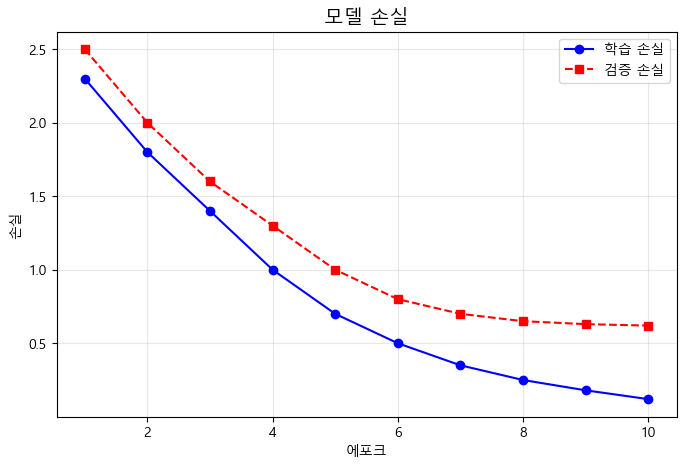

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# 그래프에서 한글을 표시하기 위한 설정
plt.rcParams['font.family'] = 'Malgun Gothic'   # 윈도우 기본 한글 글꼴
plt.rcParams['axes.unicode_minus'] = False      # 음수 부호가 깨지지 않도록 한다

# 학습 곡선을 흉내낸 데이터
epochs = list(range(1, 11))
train_loss = [2.3, 1.8, 1.4, 1.0, 0.7, 0.5, 0.35, 0.25, 0.18, 0.12]
val_loss   = [2.5, 2.0, 1.6, 1.3, 1.0, 0.8, 0.7, 0.65, 0.63, 0.62]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, 'b-o', label='학습 손실')
plt.plot(epochs, val_loss, 'r--s', label='검증 손실')
plt.title('모델 손실', fontsize=14)
plt.xlabel('에포크')
plt.ylabel('손실')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

`fig, ax = plt.subplots()` 를 쓰면 **축 객체(`ax`)** 를 직접 다루게 된다.
결과는 `plt.plot()` 방식과 같지만, 한 그림에 여러 개의 subplot 을 넣는 순간부터는 이 형태가
반드시 필요하므로 **처음부터 익혀 두는 편이 좋다.**

| 방식 | 특징 |
|------|------|
| `plt.plot()` | 간단하지만 그래프가 여러 개가 되면 다루기 불편하다 |
| `fig, ax = plt.subplots()` | 축 객체를 명시적으로 관리하고 subplot 으로 자연스럽게 확장된다 |

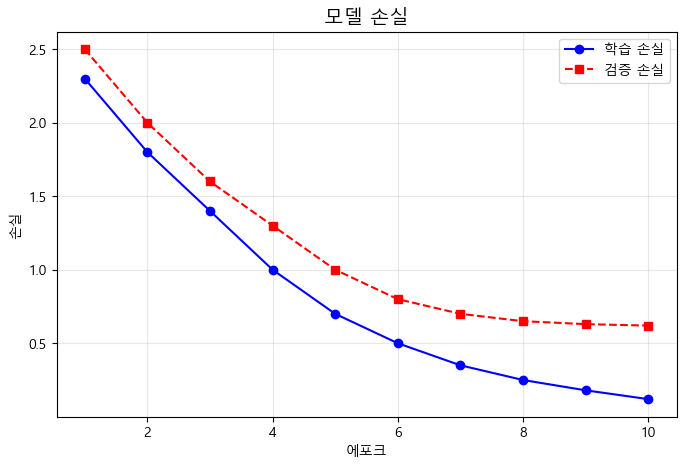

In [59]:
# 같은 그림을 fig, ax 형태로 그린 것
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, train_loss, 'b-o', label='학습 손실')
ax.plot(epochs, val_loss, 'r--s', label='검증 손실')
ax.set_title('모델 손실', fontsize=14)
ax.set_xlabel('에포크')
ax.set_ylabel('손실')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### 9.2 한 그림에 여러 그래프 그리기 (subplots)

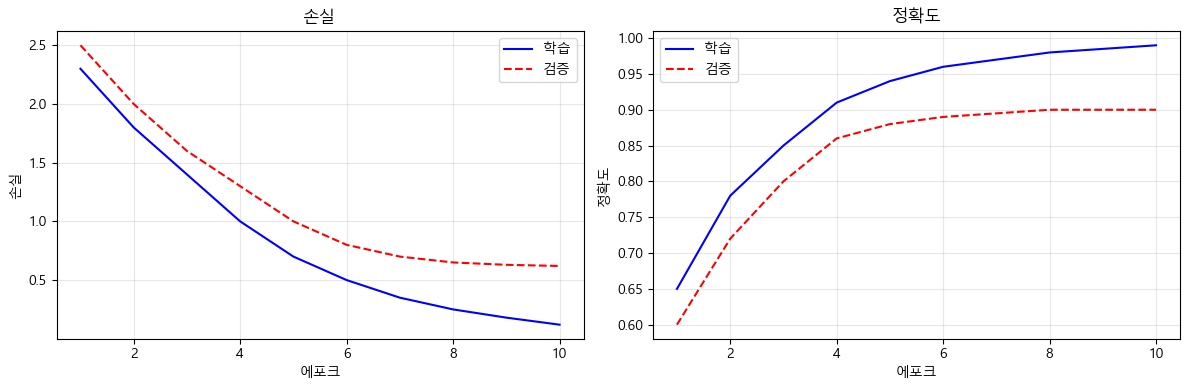

In [60]:
# 방법 1: plt.subplot() - 간단하지만 어느 축에 그리는지가 덜 명확하다
train_acc = [0.65, 0.78, 0.85, 0.91, 0.94, 0.96, 0.97, 0.98, 0.985, 0.99]
val_acc   = [0.60, 0.72, 0.80, 0.86, 0.88, 0.89, 0.895, 0.90, 0.90, 0.90]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-')
plt.plot(epochs, val_loss, 'r--')
plt.title('손실')
plt.xlabel('에포크')
plt.ylabel('손실')
plt.legend(['학습', '검증'])
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'b-')
plt.plot(epochs, val_acc, 'r--')
plt.title('정확도')
plt.xlabel('에포크')
plt.ylabel('정확도')
plt.legend(['학습', '검증'])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

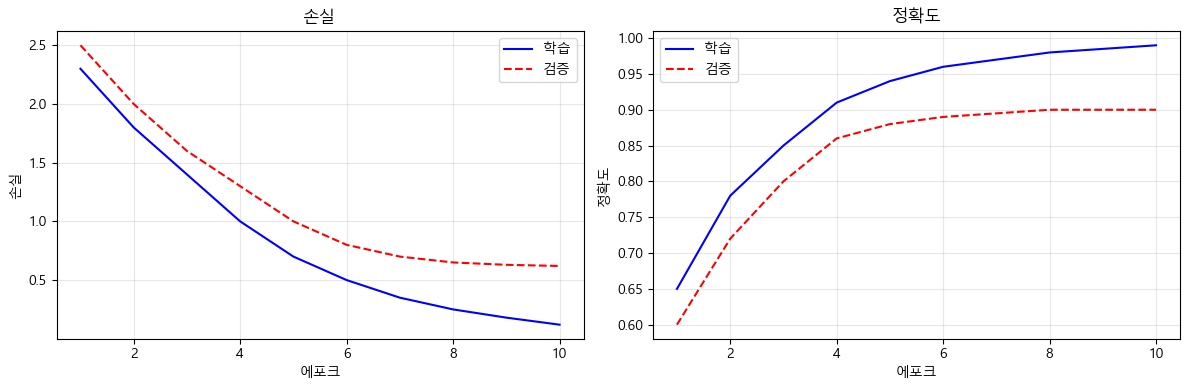

In [61]:
# 방법 2: fig, axes 형태 - 각 그래프를 axes[0], axes[1] 로 명확하게 지정한다
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽: 손실 곡선
axes[0].plot(epochs, train_loss, 'b-')
axes[0].plot(epochs, val_loss, 'r--')
axes[0].set_title('손실')
axes[0].set_xlabel('에포크')
axes[0].set_ylabel('손실')
axes[0].legend(['학습', '검증'])
axes[0].grid(True, alpha=0.3)

# 오른쪽: 정확도 곡선
axes[1].plot(epochs, train_acc, 'b-')
axes[1].plot(epochs, val_acc, 'r--')
axes[1].set_title('정확도')
axes[1].set_xlabel('에포크')
axes[1].set_ylabel('정확도')
axes[1].legend(['학습', '검증'])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.3 산점도

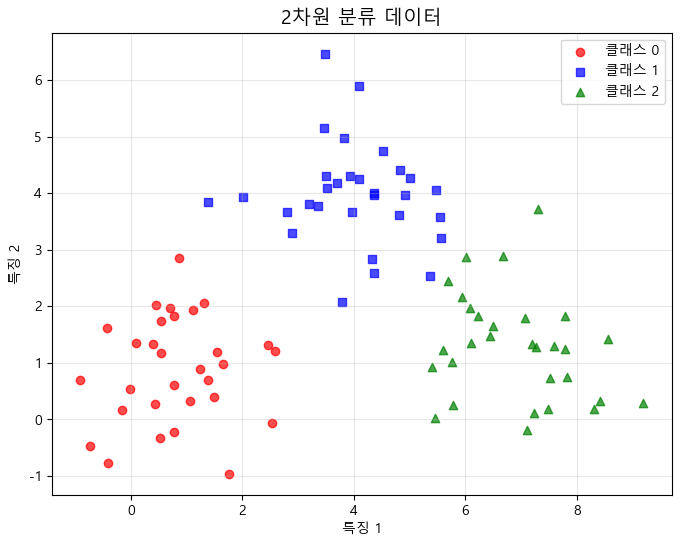

In [62]:
# 산점도 - 2차원 분류 데이터를 시각화한다
np.random.seed(42)

# 세 클래스의 2차원 데이터 (iris 와 비슷한 배치)
class0_x, class0_y = np.random.randn(30) + 1, np.random.randn(30) + 1
class1_x, class1_y = np.random.randn(30) + 4, np.random.randn(30) + 4
class2_x, class2_y = np.random.randn(30) + 7, np.random.randn(30) + 1

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(class0_x, class0_y, c='red', marker='o', label='클래스 0', alpha=0.7)
ax.scatter(class1_x, class1_y, c='blue', marker='s', label='클래스 1', alpha=0.7)
ax.scatter(class2_x, class2_y, c='green', marker='^', label='클래스 2', alpha=0.7)
ax.set_title('2차원 분류 데이터', fontsize=14)
ax.set_xlabel('특징 1')
ax.set_ylabel('특징 2')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### 9.4 히스토그램과 막대 그래프

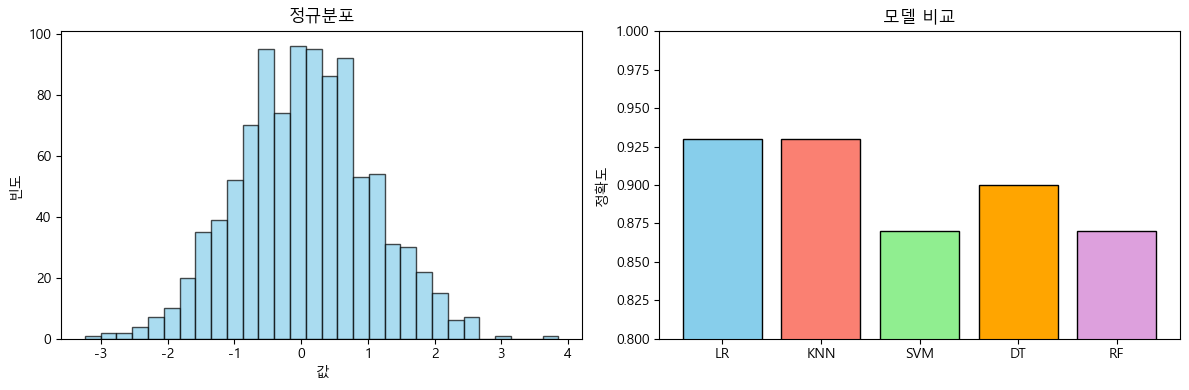

In [63]:
# 히스토그램과 막대 그래프를 나란히 그리기
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 히스토그램: 데이터의 분포
data = np.random.randn(1000)
axes[0].hist(data, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_title('정규분포')
axes[0].set_xlabel('값')
axes[0].set_ylabel('빈도')

# 막대 그래프: 모델 성능 비교
models = ['LR', 'KNN', 'SVM', 'DT', 'RF']
accuracies = [0.93, 0.93, 0.87, 0.90, 0.87]
colors = ['skyblue', 'salmon', 'lightgreen', 'orange', 'plum']
axes[1].bar(models, accuracies, color=colors, edgecolor='black')
axes[1].set_title('모델 비교')
axes[1].set_ylabel('정확도')
axes[1].set_ylim(0.8, 1.0)

plt.tight_layout()
plt.show()

### 9.5 이미지 표시하기 (imshow)

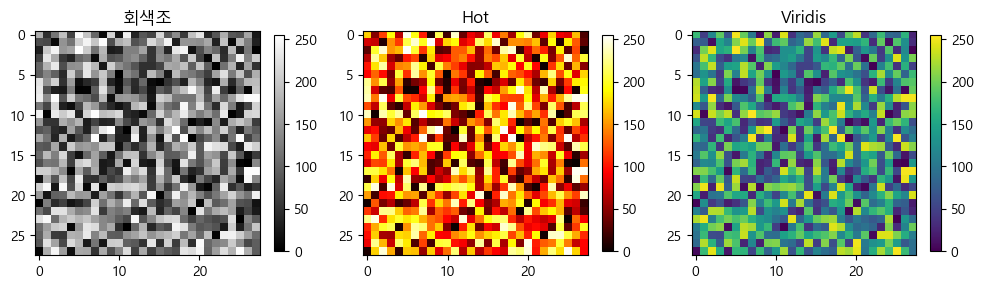

In [64]:
# imshow - 이미지를 표시한다 (DL 에서 입력 데이터를 확인할 때 필수)
np.random.seed(0)
fake_image = np.random.randint(0, 256, (28, 28))

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

# colorbar 사용법:
#   im = ax.imshow(...)   -> im 이 색상 척도를 갖는다
#   fig.colorbar(im, ax=) -> ax 로 색상 막대의 위치를 지정한다
im0 = axes[0].imshow(fake_image, cmap='gray')
axes[0].set_title('회색조')
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(fake_image, cmap='hot')
axes[1].set_title('Hot')
fig.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(fake_image, cmap='viridis')
axes[2].set_title('Viridis')
fig.colorbar(im2, ax=axes[2], shrink=0.8)

plt.tight_layout()  # subplot 사이 간격을 조정해 겹치지 않게 한다
plt.show()

### 연습문제 7

1. `y = sin(x)` 그래프를 그려라.
   (`x` 는 `np.linspace(0, 2*np.pi, 100)`, `y` 는 `np.sin(x)` 로 만든다.)
2. 같은 그림에 `y = cos(x)` 를 추가하고 범례와 제목을 붙여라.
3. (도전) `subplot` 으로 사인과 코사인을 나란히 그려라.

In [65]:
# 연습문제 7 - 여기에 답을 작성하세요
import matplotlib.pyplot as plt
import numpy as np

---
# 10. 데이터 불러오기

머신러닝 작업의 첫 단계는 **데이터를 불러와 구조를 확인하는 것**이다. 여기서는 세 가지 방식으로
데이터를 불러온다.

1. **scikit-learn** 내장 데이터셋
2. **UCI ML Repository** 데이터셋 (`fetch_openml` 사용)
3. **CSV 파일**을 내려받아 Pandas 로 읽기

### 10.1 scikit-learn 내장 데이터셋

In [66]:
# scikit-learn 내장 데이터셋: Iris (붓꽃 분류)
# 머신러닝 입문의 고전 데이터셋 - 네 개의 특징으로 세 품종을 구분한다
from sklearn.datasets import load_iris
import numpy as np

iris = load_iris()
print(type(iris))     # sklearn.utils.Bunch - 딕셔너리처럼 접근한다
print()

print("=== Iris 데이터셋 ===")
print(f"키 목록     : {list(iris.keys())}")
print(f"특징 이름   : {iris.feature_names}")
print(f"클래스 이름 : {list(iris.target_names)}")
print(f"데이터 shape: {iris.data.shape}")     # (150, 4)
print(f"레이블 shape: {iris.target.shape}")   # (150,)
print(f"레이블 값   : {np.unique(iris.target)}")  # [0 1 2]

# 처음 다섯 개 샘플
print("\n처음 5개 샘플 (특징):")
print(iris.data[:5])
print(f"처음 5개 레이블: {iris.target[:5]}")

<class 'sklearn.utils._bunch.Bunch'>

=== Iris 데이터셋 ===
키 목록     : ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']
특징 이름   : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
클래스 이름 : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
데이터 shape: (150, 4)
레이블 shape: (150,)
레이블 값   : [0 1 2]

처음 5개 샘플 (특징):
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
처음 5개 레이블: [0 0 0 0 0]


<class 'sklearn.utils._bunch.Bunch'>

=== Digits 데이터셋 ===
데이터 shape: (1797, 64)
이미지 shape: (1797, 8, 8)
클래스      : [0 1 2 3 4 5 6 7 8 9]


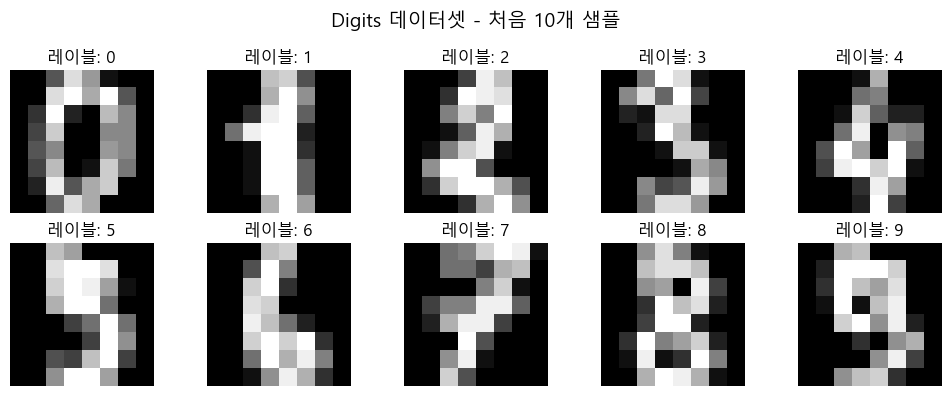

In [67]:
# scikit-learn 내장 데이터셋: Digits (손글씨 숫자 0-9)
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

digits = load_digits()
print(type(digits))
print()

print("=== Digits 데이터셋 ===")
print(f"데이터 shape: {digits.data.shape}")     # (1797, 64) - 8x8 이미지를 1차원으로 편 것
print(f"이미지 shape: {digits.images.shape}")   # (1797, 8, 8)
print(f"클래스      : {np.unique(digits.target)}")  # [0 1 2 ... 9]

# 이미지 표시하기
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"레이블: {digits.target[i]}")
    ax.axis("off")
plt.suptitle("Digits 데이터셋 - 처음 10개 샘플", fontsize=14)
plt.tight_layout()
plt.show()

### 10.2 UCI ML Repository 데이터셋

[UCI ML Repository](https://archive.ics.uci.edu/) 는 머신러닝 연구용으로 공개된 데이터셋 모음이다.
scikit-learn 의 `fetch_openml()` 은 그중 상당수를 **OpenML** 서버에서 바로 내려받는다.

In [68]:
# UCI 데이터셋: Wine Quality
# fetch_openml 은 OpenML 에 등록된 UCI 데이터셋을 내려받는다
from sklearn.datasets import fetch_openml
import pandas as pd

wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
print(type(wine))
print()

print("=== Wine Quality (Red) 데이터셋 ===")
print(f"데이터 자료형: {type(wine.data)}")
print(f"데이터 shape : {wine.data.shape}")    # (1599, 11)
print(f"레이블 shape : {wine.target.shape}")
print(f"특징 이름    : {list(wine.feature_names)}")

# DataFrame 이므로 Pandas 메서드를 바로 쓸 수 있다
print("\n--- wine.data.head() ---")
wine.data.head()

<class 'sklearn.utils._bunch.Bunch'>

=== Wine Quality (Red) 데이터셋 ===
데이터 자료형: <class 'pandas.core.frame.DataFrame'>
데이터 shape : (1599, 11)
레이블 shape : (1599,)
특징 이름    : ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']

--- wine.data.head() ---


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [69]:
# 기초 통계 - describe() 로 평균, 표준편차, 최솟값, 최댓값을 한눈에 본다
wine.data.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000


### 10.3 CSV 파일 내려받아 읽기

실제 프로젝트에서 데이터는 대개 `.csv` 파일로 온다.
`pandas.read_csv()` 는 URL 을 그대로 받으므로 내려받기와 읽기를 한 번에 처리한다.

```python
# 방법 1: URL 에서 바로 읽기 (인터넷 연결 필요)
df = pd.read_csv("https://...csv")

# 방법 2: 파일을 먼저 내려받은 뒤 읽기
# !wget https://...csv -O data.csv     # Colab 에서 내려받기
# df = pd.read_csv("data.csv")
```

In [70]:
# CSV 파일 읽기: Palmer Penguins 데이터셋
# 남극에 사는 세 펭귄 종(Adelie, Chinstrap, Gentoo)의 신체 측정값
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(url)

print("=== Penguins 데이터셋 (CSV) ===")
print(f"shape : {df.shape}")
print(f"열 이름: {list(df.columns)}")

# 처음 다섯 행
df.head()

=== Penguins 데이터셋 (CSV) ===
shape : (344, 7)
열 이름: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


---
# 11. Pandas 기초

데이터를 `pandas.DataFrame` 으로 불러오고 나면, 몇 가지 메서드만으로 일상적인 확인과 정리를
대부분 처리할 수 있다.
이 절에서는 위에서 불러온 `df` 로 그 메서드들을 살펴본다.

### 11.1 DataFrame 훑어보기

In [71]:
# 데이터 요약하기
print("--- info() : 각 열의 자료형과 결측이 아닌 값의 개수 ---")
df.info()
print("\n--- describe() : 숫자 열의 기초 통계 ---")
df.describe()

--- info() : 각 열의 자료형과 결측이 아닌 값의 개수 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB

--- describe() : 숫자 열의 기초 통계 ---


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


### 11.2 결측치 — `isnull`, `dropna`, `fillna`

In [72]:
# isnull() 은 각 칸을 True(결측) 또는 False(값 있음) 로 표시한다
print("--- isnull() : 칸마다 True/False ---")
print(df.isnull().head())

# 행 방향으로 더하면 열별 결측치 개수가 된다
print("\n--- isnull().sum() : 열별 결측치 개수 ---")
print(df.isnull().sum())

--- isnull() : 칸마다 True/False ---
   species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0    False   False           False          False              False   
1    False   False           False          False              False   
2    False   False           False          False              False   
3    False   False            True           True               True   
4    False   False           False          False              False   

   body_mass_g    sex  
0        False  False  
1        False  False  
2        False  False  
3         True   True  
4        False  False  

--- isnull().sum() : 열별 결측치 개수 ---
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [73]:
# 열 하나(Series)에 dropna() 를 쓰면 그 열의 결측치가 제거된다
sex_column = df["sex"]
print(f"dropna 전 길이: {len(sex_column)}")
print(f"dropna 후 길이: {len(sex_column.dropna())}")

dropna 전 길이: 344
dropna 후 길이: 333


In [74]:
# DataFrame 전체에 dropna() 를 쓰면 열 중 하나라도 결측인 행을 통째로 버린다
print(f"dropna() 전 행 수: {len(df)}")
print(f"dropna() 후 행 수: {len(df.dropna())}")

dropna() 전 행 수: 344
dropna() 후 행 수: 333


In [75]:
# fillna() 는 행을 버리지 않고 결측치를 다른 값으로 채운다
bill_length_filled = df["bill_length_mm"].fillna(df["bill_length_mm"].mean())    # 숫자 -> 평균
sex_filled = df["sex"].fillna(df["sex"].mode()[0])                              # 범주 -> 최빈값

print(f"bill_length_mm 결측치, 이전: {df['bill_length_mm'].isnull().sum()}, "
      f"fillna(평균) 이후: {bill_length_filled.isnull().sum()}")
print(f"sex 결측치, 이전: {df['sex'].isnull().sum()}, "
      f"fillna(최빈값) 이후: {sex_filled.isnull().sum()}")

bill_length_mm 결측치, 이전: 2, fillna(평균) 이후: 0
sex 결측치, 이전: 11, fillna(최빈값) 이후: 0


### 11.3 선택과 필터링

In [76]:
# 열 이름 하나를 주면 Series 가, 열 이름 리스트를 주면 DataFrame 이 나온다
print("--- df['species'] -> Series ---")
print(df["species"].head())
print("\n--- df[['species', 'island']] -> DataFrame ---")
print(df[["species", "island"]].head())

--- df['species'] -> Series ---
0    Adelie
1    Adelie
2    Adelie
3    Adelie
4    Adelie
Name: species, dtype: object

--- df[['species', 'island']] -> DataFrame ---
  species     island
0  Adelie  Torgersen
1  Adelie  Torgersen
2  Adelie  Torgersen
3  Adelie  Torgersen
4  Adelie  Torgersen


In [77]:
# 불리언 인덱싱: df[조건] 은 조건이 True 인 행만 남긴다
gentoo = df[df["species"] == "Gentoo"]
print(f"전체 행: {len(df)}, Gentoo 행: {len(gentoo)}")

# value_counts() 는 각 범주에 몇 개의 행이 속하는지 센다
print("\n--- 종별 개수 ---")
print(df["species"].value_counts())

전체 행: 344, Gentoo 행: 124

--- 종별 개수 ---
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


### 11.4 종합 — 데이터 시각화하기

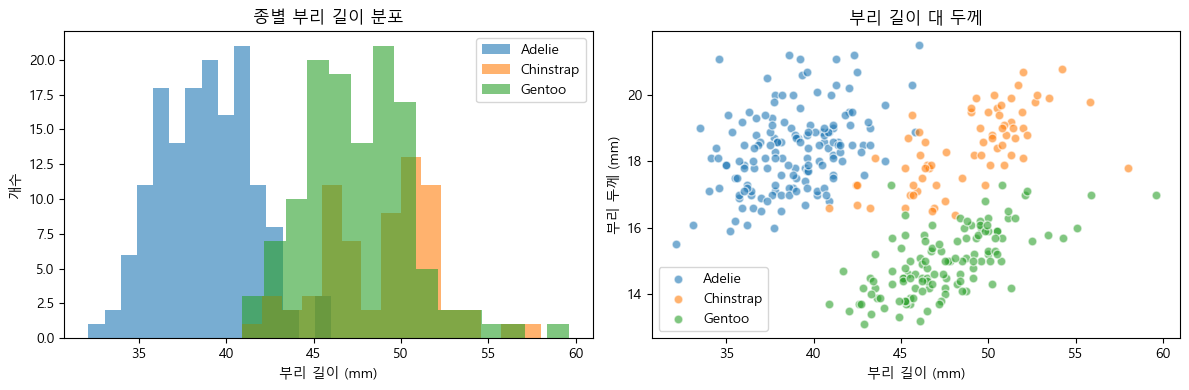

In [78]:
# 데이터를 빠르게 훑어보기: 종별 부리 길이
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (1) 종별 부리 길이 히스토그램
for species in df["species"].unique():
    subset = df[df["species"] == species]
    # bill_length_mm 에는 결측치가 몇 개 있다 - 그리기 전에 제거한다
    axes[0].hist(subset["bill_length_mm"].dropna(), bins=15, alpha=0.6, label=species)
axes[0].set_xlabel("부리 길이 (mm)")
axes[0].set_ylabel("개수")
axes[0].set_title("종별 부리 길이 분포")
axes[0].legend()

# (2) 부리 길이와 부리 두께의 산점도
colors = {"Adelie": "tab:blue", "Chinstrap": "tab:orange", "Gentoo": "tab:green"}
for species, color in colors.items():
    subset = df[df["species"] == species]
    axes[1].scatter(subset["bill_length_mm"], subset["bill_depth_mm"],
                    c=color, label=species, alpha=0.6, edgecolors="w", s=40)
axes[1].set_xlabel("부리 길이 (mm)")
axes[1].set_ylabel("부리 두께 (mm)")
axes[1].set_title("부리 길이 대 두께")
axes[1].legend()

plt.tight_layout()
plt.show()

### 연습문제 8

1. `load_iris()` 로 데이터를 불러와 **품종별 꽃잎 길이의 평균**을 구하라.
   (힌트: `iris.target` 으로 샘플을 나눈다.)
2. `penguins.csv` 에서 **Gentoo** 펭귄만 남기고 `body_mass_g` 의 평균과 표준편차를 출력하라.
3. (도전) iris 의 앞 두 특징(꽃받침 길이, 꽃받침 너비)으로 산점도를 그리되,
   품종마다 다른 색을 쓰라.

In [79]:
# 연습문제 8 - 여기에 답을 작성하세요

---
# 12. 정리

### 12.1 import 형태

앞으로 모든 실습에서 직접 입력하게 될 import 형태다.

In [80]:
# (1) 모듈 전체를 가져오기 (as: 별칭 붙이기)
import numpy as np
import matplotlib.pyplot as plt

# (2) 모듈에서 특정 함수나 클래스만 가져오기
from sklearn.datasets import load_iris
# from sklearn.model_selection import train_test_split   # 나중에 사용
# from sklearn.metrics import accuracy_score             # 나중에 사용

# 확인
print(f"NumPy 버전: {np.__version__}")
print("import 성공")

NumPy 버전: 2.1.3
import 성공


### 12.2 주로 사용하는 라이브러리

| 라이브러리 | import 형태 | 용도 |
|-----------|-------------|------|
| NumPy | `import numpy as np` | 수치 계산, 배열 연산 |
| Matplotlib | `import matplotlib.pyplot as plt` | 데이터 시각화 |
| Pandas | `import pandas as pd` | 표 형태 데이터 처리 |
| scikit-learn | `from sklearn.xxx import YYY` | 고전 머신러닝 모델 |
| PyTorch | `import torch; import torch.nn as nn` | 딥러닝 모델 |

---
# 종합 문제

### 종합 문제 1: 온도 분석 클래스

다음 조건을 만족하는 `TemperatureAnalyzer` 클래스를 작성하라.

**요구사항:**
- `__init__(self, location)`: 측정 장소 이름을 저장하고 빈 데이터 리스트를 초기화한다
- `add_data(self, *temperatures)`: 여러 개의 온도 측정값을 한 번에 추가한다 (`*args` 사용)
- `get_stats(self)`: 평균, 최고, 최저 온도를 딕셔너리로 반환한다
- `get_above(self, threshold)`: `threshold` 이상인 측정값을 리스트로 반환한다
  (리스트 컴프리헨션 사용)
- `plot(self)`: matplotlib 으로 온도 변화를 그린다

**테스트 코드:**
```python
analyzer = TemperatureAnalyzer("Lab A")
analyzer.add_data(22.1, 23.5, 24.0, 22.8, 25.1, 23.2, 24.5)
print(analyzer.get_stats())
print(f"24도 이상: {analyzer.get_above(24.0)}")
analyzer.plot()
```

In [81]:
# 종합 문제 1 - 여기에 답을 작성하세요
import matplotlib.pyplot as plt

class TemperatureAnalyzer:
    pass  # 여기에 구현을 작성하세요


# 테스트
# analyzer = TemperatureAnalyzer("Lab A")
# analyzer.add_data(22.1, 23.5, 24.0, 22.8, 25.1, 23.2, 24.5)
# print(analyzer.get_stats())
# print(f"24도 이상: {analyzer.get_above(24.0)}")
# analyzer.plot()

### 종합 문제 2: NumPy 로 만드는 뉴런 하나

뉴런 하나(퍼셉트론)의 동작을 구현하라.

**뉴런이 하는 일:**
1. 입력: `x = [x1, x2, x3]` (NumPy 배열)
2. 가중치: `w = [w1, w2, w3]` (NumPy 배열)
3. 편향: `b` (스칼라)
4. 출력: `y = 1 if (w . x + b) > 0 else 0`

**요구사항:**
- 내적은 `np.dot()` 으로 계산한다
- `for` 반복문으로 여러 입력 샘플에 대해 예측한다
- 결과는 f-string 으로 출력한다

In [82]:
# 종합 문제 2 - 여기에 답을 작성하세요
import numpy as np

# 가중치와 편향
w = np.array([0.5, -0.3, 0.8])
b = -0.1

# 테스트 입력 (샘플 3개)
X = np.array([
    [1.0, 0.5, 0.8],
    [0.2, 0.9, 0.1],
    [0.7, 0.3, 0.9]
])

# 여기에 구현을 작성하세요
# 각 샘플에 대해 z = w . x + b 를 계산하고
# z > 0 이면 1, 아니면 0 을 출력한다

### 종합 문제 3: 경사하강법 시뮬레이터

힌트의 수식을 이용해 경사하강법 반복으로 `y = 3x + 2` 의 기울기와 절편을 찾아라.

**단계:**
1. 데이터: `x = np.linspace(0, 10, 50)`, `y = 3*x + 2 + 잡음`
2. `w = 0.0`, `b = 0.0` 에서 시작한다
3. 100번 반복하며 `w` 와 `b` 를 갱신한다
4. `subplot`: 데이터와 적합된 직선, 그리고 손실의 변화

**힌트:**
```python
y_pred = w * x + b
loss = np.mean((y - y_pred) ** 2)
dw = -2 * np.mean(x * (y - y_pred))
db = -2 * np.mean(y - y_pred)
w = w - lr * dw
b = b - lr * db
```

In [83]:
# 종합 문제 3 - 여기에 답을 작성하세요
import numpy as np
import matplotlib.pyplot as plt

# 여기에 구현을 작성하세요

---
## 마무리

**핵심 정리:**

| 주제 | 핵심 키워드 |
|------|------------|
| 변수 / 자료형 | `int`, `float`, `str`, `bool`, `type()` |
| 자료구조 | `list[ ]`, `tuple( )`, `dict{ }`, `.items()` |
| 제어문 | `if/elif/else`, `for`, `while`, `enumerate`, `zip` |
| 함수 | `def`, `return`, `*args`, `**kwargs` |
| 간결한 문법 | 리스트 컴프리헨션, `lambda` |
| 문자열 | f-string, `.format()`, `.split()`, `.join()` |
| 클래스 | `class`, `__init__`, `self`, 상속, `super()` |
| NumPy | `np.array`, `dtype`, `astype`, `reshape`, 인덱싱, `@` |
| Matplotlib | `plt.plot`, `fig, axes`, `plt.scatter`, `plt.imshow` |